In [1]:
import numpy as np

In [41]:
v = np.array([3,1])
d = np.array([4,2])
v

array([3, 1])

In [4]:
import matplotlib.pyplot as plt

In [39]:
def plot_arrow_vectors(vectors,colors):
    plt.figure()
    plt.axvline(x=0,color='lightgray')
    plt.axhline(y=0,color='lightgray')

    for i in range(len(vectors)):
        x = np.concatenate([[0,0],vectors[i]])
        plt.quiver(
            [x[0]], [x[1]],      # Start point (0,0)
            [x[2]], [x[3]],      # Arrow direction (dx, dy)
            angles='xy',
            scale_units='xy',
            scale=1,
            color=colors[i]
        )

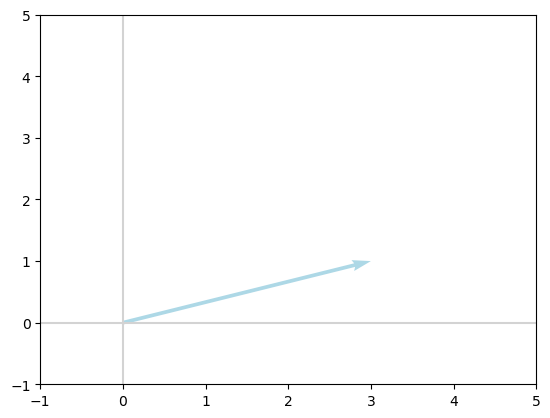

In [45]:
plot_arrow_vectors([v],['lightblue'])
plt.xlim(-1,5)
_=plt.ylim(-1,5)

In [48]:
# apply identity matrix
I = np.array([[1,0],[0,1]])
I

array([[1, 0],
       [0, 1]])

In [51]:
Iv = np.dot(I,v)
Iv

array([3, 1])

(-1.0, 5.0)

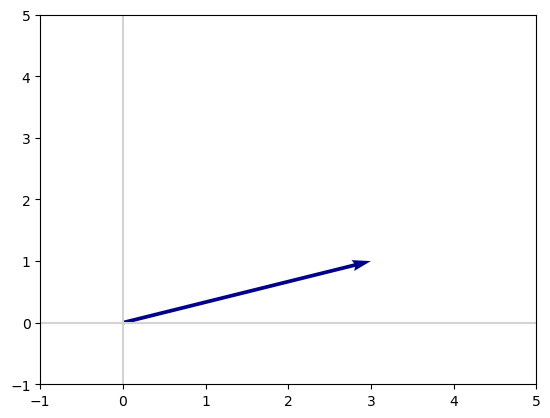

In [54]:
plot_arrow_vectors([Iv],['darkblue'])
plt.xlim(-1,5)
plt.ylim(-1,5)

In [67]:
Inv = np.array([[1,0],[0,-1]])
Inv

array([[ 1,  0],
       [ 0, -1]])

In [68]:
Ev = np.dot(Inv,v)
Ev

array([ 3, -1])

(-1.0, 5.0)

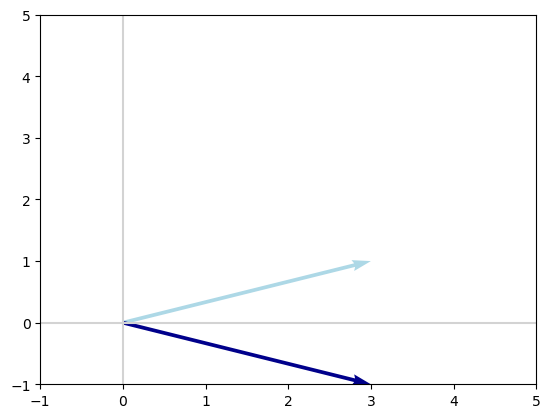

In [69]:
plot_arrow_vectors([v,Ev],['lightblue','darkblue'])
plt.xlim(-1,5)
plt.ylim(-1,5)

In [65]:
F = np.array([[-1,0],[0,1]])
F

array([[-1,  0],
       [ 0,  1]])

In [66]:
Fv = np.dot(F,v)
Fv

array([-3,  1])

(-2.0, 5.0)

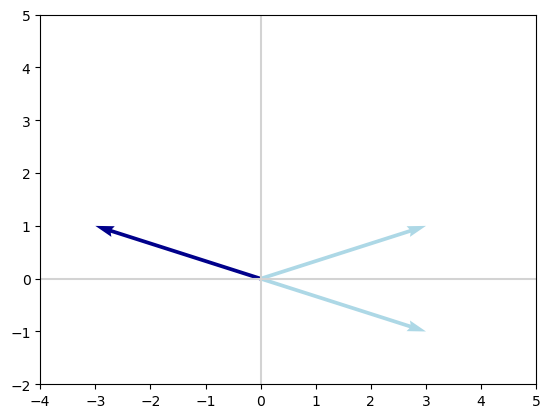

In [78]:
plot_arrow_vectors([v,Ev,Fv],['lightblue','lightblue','darkblue'])
plt.xlim(-4,5)
plt.ylim(-2,5)

#### Applying a flipping matrix is an example of an **affine transformation**
In addition to flipping matrix, also other examples are:
- Scaling (Changing the length of vector)
- Shearing (Example on mona lisa painting coming next)
- Rotation

A Single matrix can apply multiple affine transforms simultaneously (e.g., flip over an axis and applying 45 degree angle).

In [79]:
A = np.array([[-1,4],[2,-2]])
A

array([[-1,  4],
       [ 2, -2]])

In [80]:
Av = np.dot(A,v)
Av

array([1, 4])

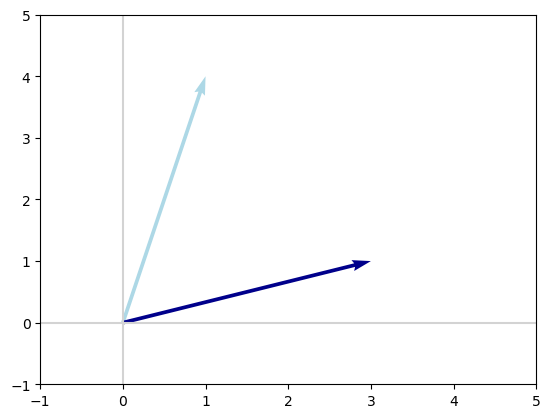

In [87]:
plot_arrow_vectors([Av,v],['lightblue','darkblue'])
plt.xlim(-1,5)
_=plt.ylim(-1,5)

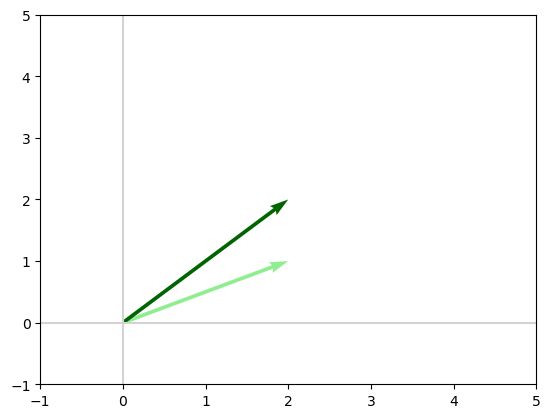

In [88]:
# Another example of applying A:
v2 = np.array([2,1])
plot_arrow_vectors([v2,np.dot(A,v2)],['lightgreen','darkgreen'])
plt.xlim(-1,5)
_=plt.ylim(-1,5)

We can concatenate several vectors togather into matrix(say, V), where each column is a separate vector. Then, whatever linear transformations we apply to v will be applied to each column independently 

In [89]:
v

array([3, 1])

In [90]:
# recall that we can take transpose to convert a row into columns
np.matrix(v).T

matrix([[3],
        [1]])

In [91]:
v3 = np.array([-3,-1])
v4 = np.array([-1,-1])

In [96]:
V = np.concatenate((np.matrix(v).T,
                    np.matrix(v2).T,
                    np.matrix(v3).T,
                    np.matrix(v4).T),
                   axis=1)
V

matrix([[ 3,  2, -3, -1],
        [ 1,  1, -1, -1]])

In [97]:
IV = np.dot(I,V)
IV

matrix([[ 3,  2, -3, -1],
        [ 1,  1, -1, -1]])

In [98]:
AV = np.dot(A,V)
AV

matrix([[ 1,  2, -1, -3],
        [ 4,  2, -4,  0]])

In [102]:
# function to convert column of matrix to 1D vector:
def vectorfy(mtrx,clmn):
    return np.array(mtrx[:,clmn]).reshape(-1)

In [103]:
vectorfy(V,0)

array([3, 1])

In [104]:
vectorfy(V,0)==v

array([ True,  True])

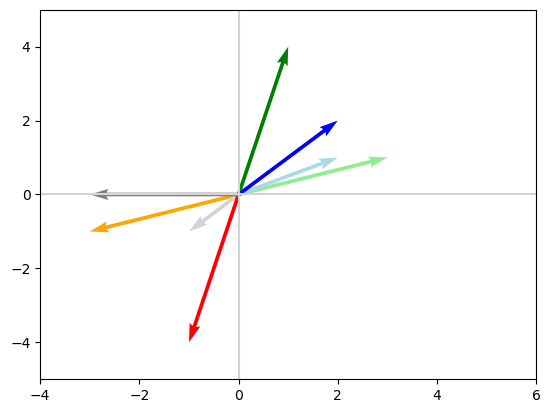

In [111]:
plot_arrow_vectors([vectorfy(V,0),vectorfy(V,1),vectorfy(V,2),vectorfy(V,3),
                   vectorfy(AV,0),vectorfy(AV,1),vectorfy(AV,2),vectorfy(AV,3)],
                   ['lightgreen','lightblue','orange','lightgray',
                   'green','blue','red','gray'])
plt.xlim(-4,6)
_=plt.ylim(-5,5)

In [112]:
A

array([[-1,  4],
       [ 2, -2]])

In [114]:
lambdas,V = np.linalg.eig(A)

In [115]:
V # each column is a vector it self

array([[ 0.86011126, -0.76454754],
       [ 0.51010647,  0.64456735]])

In [116]:
lambdas # corresponding eigenvalue of each vector 

array([ 1.37228132, -4.37228132])

#### lets confirm the A.v = lambda.v

In [118]:
v = V[:,0]
v

array([0.86011126, 0.51010647])

In [120]:
Av = np.dot(A,v)
Av

array([1.18031462, 0.70000958])

In [121]:
lambda1 = lambdas[0]
lambda1

np.float64(1.3722813232690143)

In [123]:
lambda1v = np.dot(lambda1,v)
lambda1v

array([1.18031462, 0.70000958])

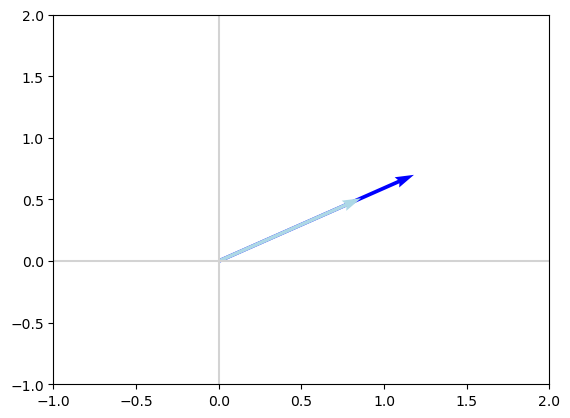

In [130]:
plot_arrow_vectors([Av,v],['blue','lightblue'])
plt.xlim(-1,2)
_= plt.ylim(-1,2)

#### Now for second vector from V as we have discussed, in V **every column is a vector** it self

In [131]:
v2 = V[:,1]
v2

array([-0.76454754,  0.64456735])

In [132]:
Av2 = np.dot(A,v2)
Av2

array([ 3.34281692, -2.81822977])

In [133]:
lambda2 = lambdas[1]
lambda2

np.float64(-4.372281323269014)

In [134]:
lambda2v = np.dot(lambda2,v2)
lambda2v

array([ 3.34281692, -2.81822977])

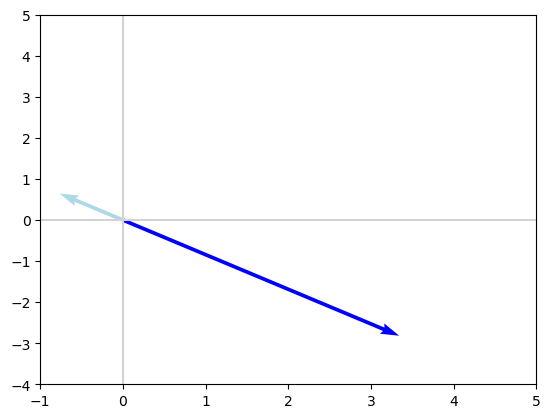

In [137]:
plot_arrow_vectors([Av2,v2],['blue','lightblue'])
plt.xlim(-1,5)
_=plt.ylim(-4,5)

#### Plotting both at same plane

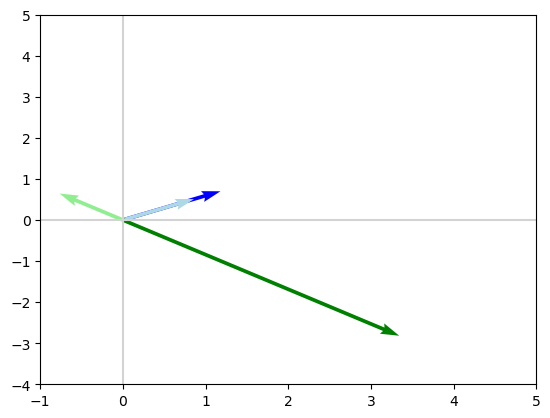

In [138]:
plot_arrow_vectors([Av,v,Av2,v2],['blue','lightblue','green','lightgreen'])
plt.xlim(-1,5)
_=plt.ylim(-4,5)

### Another example explaining the eigen vectors and eigen values

(np.float64(-0.05500000000000001),
 np.float64(0.05500000000000001),
 np.float64(-0.05500000000000001),
 np.float64(0.05500000000000001))

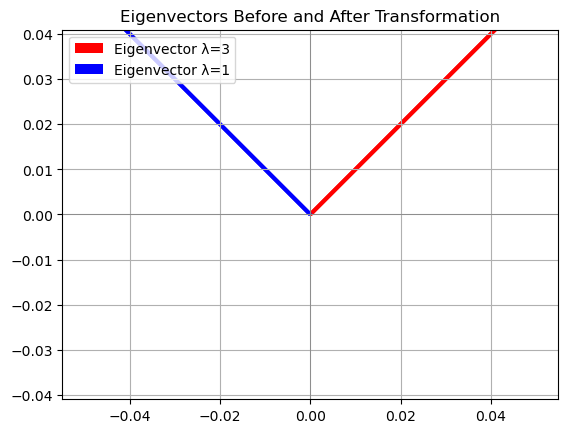

In [147]:
A = np.array([[2, 1],
              [1, 2]])

# Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(A)

origin = np.array([[0, 0], [0, 0]])  # origin point
v1 = eigenvectors[:, 0]
v2 = eigenvectors[:, 1]

# Plot original eigenvectors
plt.quiver(*origin, v1[0], v1[1], color='r', scale=1, label="Eigenvector λ=3")
plt.quiver(*origin, v2[0], v2[1], color='b', scale=1, label="Eigenvector λ=1")

# Apply transformation to eigenvectors
Av1 = A @ v1
Av2 = A @ v2

# Plot transformed vectors
plt.quiver(*origin, Av1[0], Av1[1], color='r', scale=1, linestyle='dashed')
plt.quiver(*origin, Av2[0], Av2[1], color='b', scale=1, linestyle='dashed')

plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid()
plt.legend()
plt.title("Eigenvectors Before and After Transformation")
plt.axis('equal')

### Determinants # Eigen Value

In [150]:
X = np.array([
    [1,2,4],
    [2,-1,3],
    [0,5,1]])
X

array([[ 1,  2,  4],
       [ 2, -1,  3],
       [ 0,  5,  1]])

In [152]:
detx=np.abs(np.linalg.det(X))
detx

np.float64(19.999999999999996)

#### let's use a matrix B, which is composed of basis vectors, to explore the impact of applying matrices with varying **detx** values:

In [153]:
B = np.array([[1,0],[0,1]])
B

array([[1, 0],
       [0, 1]])

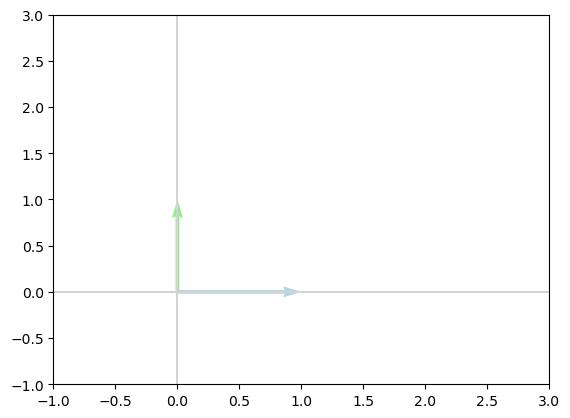

In [156]:
plot_arrow_vectors([vectorfy(B,0),vectorfy(B,1)],['lightblue','lightgreen'])
plt.xlim(-1,3)
_=plt.ylim(-1,3)

In [158]:
X

array([[ 1,  2,  4],
       [ 2, -1,  3],
       [ 0,  5,  1]])

## Eigen Decomposition: 
### Eigen values and eigen vectors exposes the characteristics of the matrix
- Matrix is singular if and only if its eigenvalues are zero
- Under specific conditions:
    - Maximum of f[x] = largest eigen value
    - Minimum of f[x] = smallest eigen value
#### Eigen Decomposistion of any A matrix is,
A = V(uppercase-lambda)V^-1

In [160]:
A = np.array([[4,2],[-5,-3]])
A

array([[ 4,  2],
       [-5, -3]])

In [162]:
lambdas, V = np.linalg.eig(A)
V

array([[ 0.70710678, -0.37139068],
       [-0.70710678,  0.92847669]])

In [163]:
Vinv = np.linalg.inv(V)
Vinv

array([[2.3570226 , 0.94280904],
       [1.79505494, 1.79505494]])

In [164]:
LAMBDA = np.diag(lambdas)
LAMBDA

array([[ 2.,  0.],
       [ 0., -1.]])

##### Confirm that, A = V(uppercase lambda)V^-1

In [166]:
np.dot(V,np.dot(LAMBDA,Vinv))

array([[ 4.,  2.],
       [-5., -3.]])

### SVD: Singular Vector Decomposition
As per fomula we have to prove, A = UDVt

In [167]:
A = np.array([[-1,2],[3,-2],[5,7]])
A

array([[-1,  2],
       [ 3, -2],
       [ 5,  7]])

In [168]:
U, d, Vt = np.linalg.svd(A)
print(f'U: {U}')
print(f'd: {d}')
print(f'Vt: {Vt}')

U: [[ 0.12708324  0.47409506  0.87125411]
 [ 0.00164602 -0.87847553  0.47778451]
 [ 0.99189069 -0.0592843  -0.11241989]]
d: [8.66918448 4.10429538]
Vt: [[ 0.55798885  0.82984845]
 [-0.82984845  0.55798885]]


In [169]:
D = np.concatenate((np.diag(d),[[0,0]]),axis=0)
D

array([[8.66918448, 0.        ],
       [0.        , 4.10429538],
       [0.        , 0.        ]])

In [170]:
np.dot(U,np.dot(D,Vt))

array([[-1.,  2.],
       [ 3., -2.],
       [ 5.,  7.]])

⬆️ hence we prove above that A = UDVt

## Image compression with SVD

In [172]:
from PIL import Image #PIL stands for python imaging library

fetch photo of Oboe, from a book online

In [176]:
!brew install wget

==> Auto-updating Homebrew...
Adjust how often this is run with HOMEBREW_AUTO_UPDATE_SECS or disable with
HOMEBREW_NO_AUTO_UPDATE. Hide these hints with HOMEBREW_NO_ENV_HINTS (see `man brew`).
==> Downloading https://ghcr.io/v2/homebrew/portable-ruby/portable-ruby/blobs/sha256:40e7f5d7514a7e9757facdd39006f7a351d3d7986d3a228be13c8b1c3216727b
######################################################################### 100.0%
==> Pouring portable-ruby-3.4.3.arm64_big_sur.bottle.tar.gz
==> Auto-updated Homebrew!
Updated 2 taps (homebrew/core and homebrew/cask).
==> New Formulae
bkmr                       infat                      sequoia-chameleon-gnupg
camlpdf                    kubectl-ai                 sexpect
codex                      miniflux                   swiftly
cpdf                       nerdlog                    tdom
e2b                        newsraft                   tmex
elfio                      pieces-cli                 tmuxai
girara                     pixd          

In [177]:
!wget https://raw.githubusercontent.com/jonkrohn/DLTFpT/master/notebooks/oboe-with-book.jpg

--2025-05-12 13:09:29--  https://raw.githubusercontent.com/jonkrohn/DLTFpT/master/notebooks/oboe-with-book.jpg
185.199.111.133, 185.199.109.133, 185.199.110.133, ...tent.com)... 
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 419564 (410K) [image/jpeg]
Saving to: ‘oboe-with-book.jpg’

oboe-with-book.jpg  100%[===================>] 409.73K  --.-KB/s    in 0.1s    

2025-05-12 13:09:30 (3.70 MB/s) - ‘oboe-with-book.jpg’ saved [419564/419564]



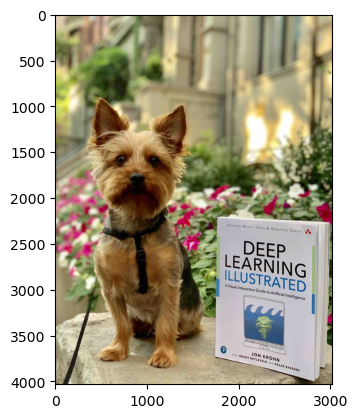

In [178]:
img = Image.open('oboe-with-book.jpg')
_ = plt.imshow(img)

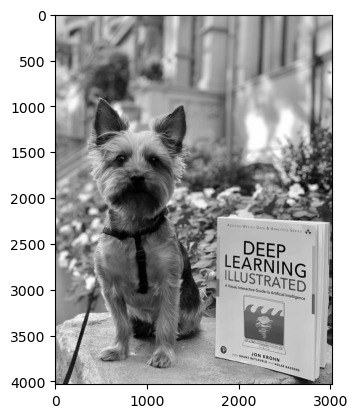

In [181]:
# convert image into grayscale
imggray = img.convert('LA')
_=plt.imshow(imggray)

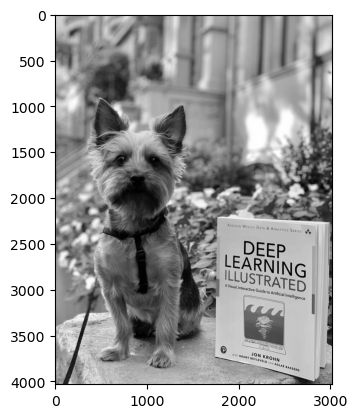

In [190]:
# convert image data into matrix
imgmat = np.array((imggray.getdata(band=0)),float)
imgmat.shape = (imggray.size[1],imggray.size[0])
imgmat = np.matrix(imgmat)
_ = plt.imshow(imgmat,cmap='gray')

In [192]:
#Calculate SVD of the image
U, sigma, V = np.linalg.svd(imgmat)

##### As eigenvalues are arranged in descending order in diag(lambda) so to are singular values, by convention, arranged in descending order in D. Thus, first left singular vector of U and first right singular vector of U may represent the most prominent feature of the image:

###### Here is detailed:
- U = first left of singular vector of a matrix
- sigma = diagonal of a singular vector of matrix
- V = first right of singular vector of a matrix

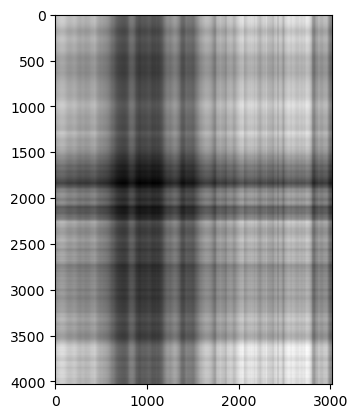

In [193]:
reconstimg = np.matrix(U[:,:1])*np.diag(sigma[:1])*np.matrix(V[:1,:])
_=plt.imshow(reconstimg,cmap='gray')

##### Additional Singular vectors improve the image quality

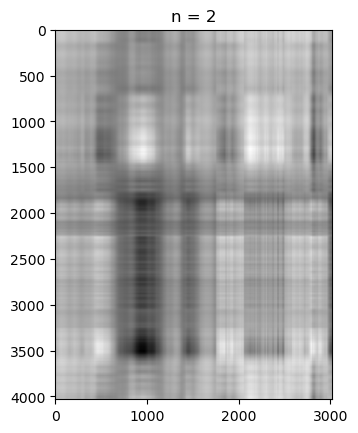

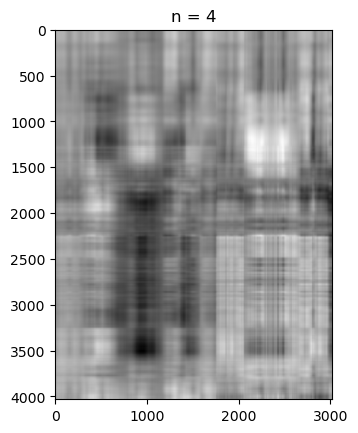

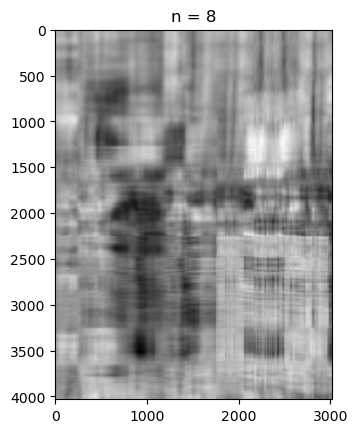

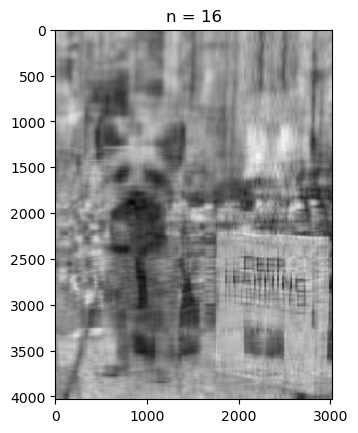

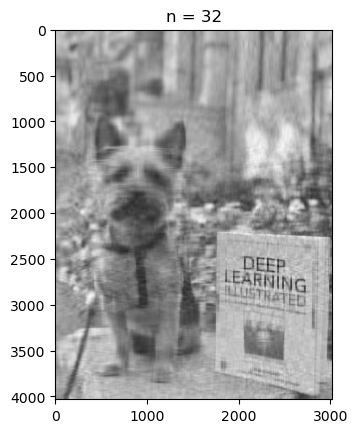

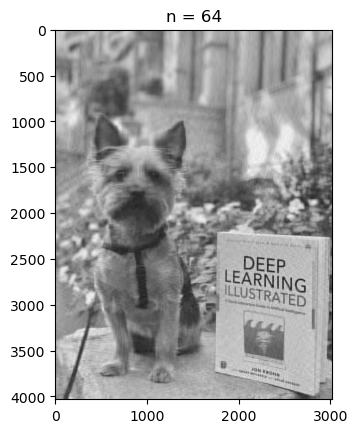

In [198]:
for i in [2,4,8,16,32,64]:
    reconstimg = np.matrix(U[:,:i])*np.diag(sigma[:i])*np.matrix(V[:i,:])
    plt.imshow(reconstimg,cmap='gray')
    title = f'n = {i}'
    plt.title(title)
    plt.show()

##### With 64 singular vectors, the image is reconstructed quite well, however the data footprint is much smaller than the original image:

In [200]:
imgmat.shape

4032

In [201]:
full_representative = np.dot(imgmat.shape[0],imgmat.shape[1])
full_representative

np.int64(12192768)

all datapoints in a plane of 64 vector points

In [202]:
svd64_representative = 64*imgmat.shape[0]+64+imgmat.shape[1]*64
svd64_representative

451648

In [203]:
svd64_representative/full_representative

np.float64(0.037042286050222556)

##### Specifically, the image representated as 64 singular vectors is 3.7% of the size of the original!
Alongside images, we can use singular vector for dramatic, lossy compression of other types of media files

### The Moore-Penrose Pseudoinverse
Let's calculate the pseudoinverse $A^+$ of some matrix A using formula: 
$A^+ = U D^+ V^t$

In [204]:
A

array([[-1,  2],
       [ 3, -2],
       [ 5,  7]])

As shown earlier that SVD from numpy returns, $U,D,V^t$

In [209]:
U,d,Vt = np.linalg.svd(A)
print(f'U: {U}')
print(f'd: {d}')
print(f'Vt: {Vt}')

U: [[ 0.12708324  0.47409506  0.87125411]
 [ 0.00164602 -0.87847553  0.47778451]
 [ 0.99189069 -0.0592843  -0.11241989]]
d: [8.66918448 4.10429538]
Vt: [[ 0.55798885  0.82984845]
 [-0.82984845  0.55798885]]


##### Calculate $D^+$

In [210]:
D = np.diag(d)
D

array([[8.66918448, 0.        ],
       [0.        , 4.10429538]])

Now taking the transpose of the resulting Matrix *D*
Because *D* is the diagonal matrix, this can,however, be done with a single operating by taking inverse of *D*

In [211]:
Dinv = np.linalg.inv(D)
Dinv

array([[0.1153511 , 0.        ],
       [0.        , 0.24364718]])

In [212]:
Dplus = np.concatenate((Dinv,np.array([[0,0]]).T),axis=1)
Dplus

array([[0.1153511 , 0.        , 0.        ],
       [0.        , 0.24364718, 0.        ]])

Now we have everything we need to solve according to formula

In [215]:
np.dot(Vt.T,np.dot(Dplus,U.T))

array([[-0.08767773,  0.17772512,  0.07582938],
       [ 0.07661927, -0.1192733 ,  0.08688784]])

#### We can achieve the above same with a direct method from Numpy

In [216]:
np.linalg.pinv(A)

array([[-0.08767773,  0.17772512,  0.07582938],
       [ 0.07661927, -0.1192733 ,  0.08688784]])

For regression problems, we typically have many more cases (, or rows of ) than features to predict (columns of ). Let's solve a miniature example of such an overdetermined situation.

We have eight data points ( = 8):

In [217]:
x1 = [0, 1, 2, 3, 4, 5, 6, 7.] # E.g.: Dosage of drug for treating Alzheimer's disease
y = [1.86, 1.31, .62, .33, .09, -.67, -1.23, -1.37] # E.g.: Patient's "forgetfulness score"

In [218]:
title = 'Clinical Trial'
xlabel = 'Drug dosage (mL)'
ylabel = 'Forgetfulness'

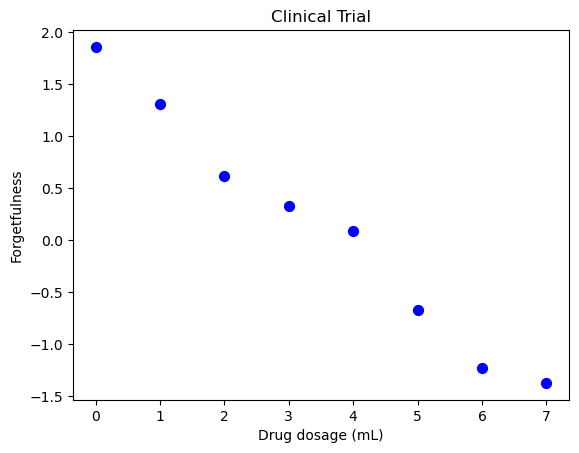

In [230]:
fig,ax = plt.subplots()
plt.title(title)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
_=ax.scatter(x1,y,color='blue', s=50, label='Patients') # scatter is used to plot the data in a graph where coordinates have to be multiple


Although it appears there is only one predictor (), our model requires a second one (let's call it ) in order to allow for a -intercept. Without this second variable, the line we fit to the plot would need to pass through the origin (0, 0). The -intercept is constant across all the points so we can set it equal to 1 across the board:

In [231]:
x0 = np.ones(8)
x0

array([1., 1., 1., 1., 1., 1., 1., 1.])

Concatenate the x0 and x1 into a matrix X:

In [233]:
X = np.concatenate((np.matrix(x0).T,np.matrix(x1).T),axis=1)
X

matrix([[1., 0.],
        [1., 1.],
        [1., 2.],
        [1., 3.],
        [1., 4.],
        [1., 5.],
        [1., 6.],
        [1., 7.]])

Now we will calculate w as per formula

In [234]:
w = np.dot(np.linalg.pinv(X),y)
w

matrix([[ 1.76      , -0.46928571]])

In [235]:
b = np.asarray(w).reshape(-1)[0]
b

np.float64(1.7599999999999993)

In [236]:
m = np.asarray(w).reshape(-1)[1]
m

np.float64(-0.4692857142857143)

With these lines we can confirm these points by plotting the graph

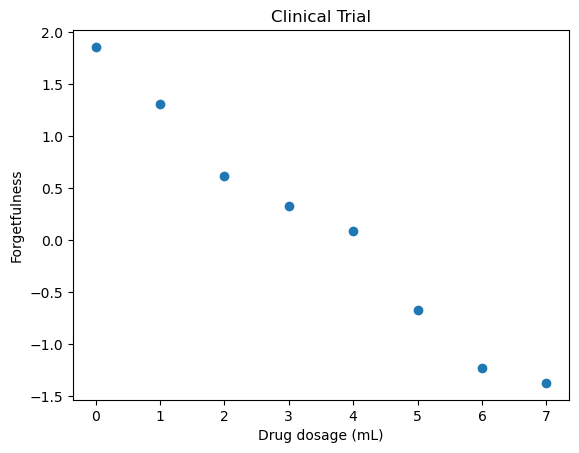

In [238]:
fig,ax = plt.subplots()
plt.title(title)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
ax.scatter(x1,y)
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

ax.set_xlim([x_min,x_max])
_=ax.set_ylim([y_min,y_max])

With the weights we can plot the line to confirm it fits the points

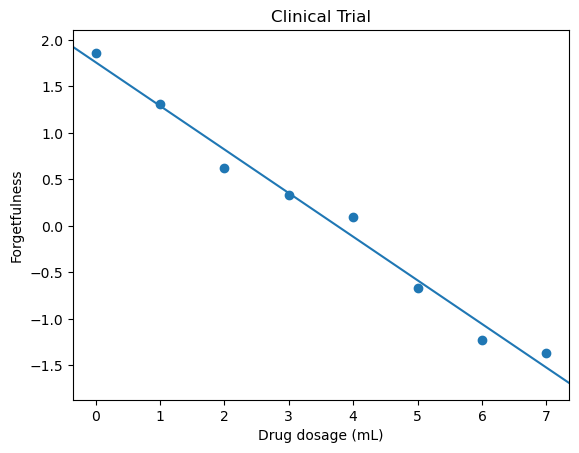

In [239]:
fig,ax = plt.subplots()
plt.title(title)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
ax.scatter(x1,y)
x_min, x_max = ax.get_xlim()
y_min, y_max = m*x_min + b, m*x_max+b

ax.set_xlim([x_min,x_max])
_=ax.plot([x_min,x_max],[y_min,y_max])

### The Trace Operator

In [240]:
A = np.array([[25,2],[5,4]])
A

array([[25,  2],
       [ 5,  4]])

In [241]:
25+4

29

In [242]:
np.trace(A)

np.int64(29)

## PCA: Principal Component Analysis
Given a dataset with 4 features, we aim to reduce it to 2 principal components that capture the most variance. PCA, a decomposition technique, helps identify these directions by projecting the data onto a lower-dimensional subspace while preserving as much information as possible.

In [244]:
from sklearn import datasets
iris = datasets.load_iris()

In [248]:
iris.data.shape

(150, 4)

In [247]:
iris.get('feature_names')

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [249]:
iris.data[0:6,:]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4]])

In [251]:
from sklearn.decomposition import PCA

In [252]:
pca = PCA(n_components=2)

In [254]:
X = pca.fit_transform(iris.data)
X.shape

(150, 2)

In [256]:
X[0:6,] # got the first 6 rows from a variable array X

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045]])

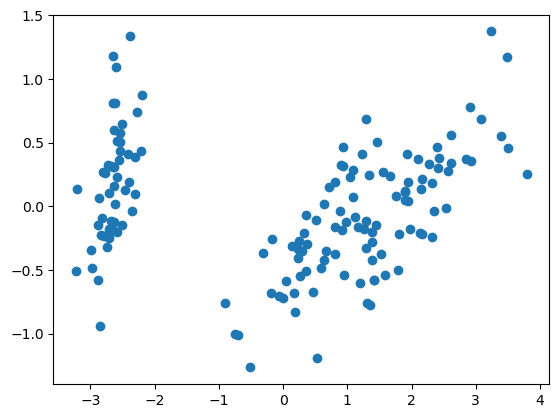

In [258]:
_ = plt.scatter(X[:,0],X[:,1])

In [259]:
iris.target.shape

(150,)

In [260]:
iris.target[0:6]

array([0, 0, 0, 0, 0, 0])

In [264]:
unique_elements, counts_elements = np.unique(iris.target,return_counts=True)
np.asarray((unique_elements,counts_elements))

array([[ 0,  1,  2],
       [50, 50, 50]])

In [266]:
list(iris.target_names)

[np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]